<a href="https://colab.research.google.com/github/Alaa-elden-mohammed/Dubai-real-estate-predictor/blob/main/01_eda_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install kaggle pandas numpy matplotlib seaborn geopy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [3]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!kaggle datasets download -d sergionefedov/dubai-real-estate-sales-and-rentals-20202026 -p ./data --unzip

Dataset URL: https://www.kaggle.com/datasets/sergionefedov/dubai-real-estate-sales-and-rentals-20202026
License(s): apache-2.0
100% 3.89M/3.89M [00:01<00:00, 3.08MB/s]



In [4]:
import os
print(os.listdir('./data'))

['rentals.csv', 'secondary_sales.csv', 'metro_stations.csv', 'off_plan.csv', 'area_prices_monthly.csv']


In [6]:
df = pd.read_csv('./data/secondary_sales.csv')
print(df.shape)
df.head()

(50000, 29)


,id,date_listed,community,zone,is_freehold,lat,lon,property_category,property_type,bedrooms,area_sqft,area_m2,floor,total_floors,year_built,view,furnishing,condition,parking_spaces,chiller_included,metro_station,metro_line,metro_distance_min,metro_distance_type,to_burj_khalifa_km,price_usd,price_per_sqft_usd,price_per_m2_usd,mortgage_rate_at_listing
0,S000001,2024-11-23,DIFC,DIFC,True,25.21053,55.29453,apartment,4BR_penthouse,4,3658,339.9,11.0,20.0,2021,burj_khalifa,unfurnished,vacant_on_transfer,2,True,Financial Centre,Red,6,walk,2.51,4806100,1314,14141,6.15
1,S000002,2023-07-05,DIFC,DIFC,True,25.21330,55.28617,apartment,3BR,3,1783,165.6,43.0,60.0,2021,golf_course,unfurnished,tenanted,1,True,Emirates Towers,Red,13,walk,2.15,2287400,1283,13813,6.90
2,S000003,2022-01-22,Karama,Bur Dubai,False,25.24835,55.29501,apartment,1BR,1,824,76.5,14.0,30.0,2012,park,unfurnished,tenanted,2,False,BurJuman (G),Green,14,walk,6.05,167100,203,2184,1.90
3,S000004,2021-10-28,The Valley,Dubai-Al Ain Road,True,24.95989,55.48870,villa,5BR_villa,5,5401,501.8,NaN,NaN,2021,community,semi_furnished,tenanted,3,False,Discovery Gardens,Red,151,drive,34.09,832000,154,1658,1.90
4,S000005,2025-05-30,Sobha Hartland,MBR City,True,25.17393,55.28697,apartment,3BR,3,2005,186.3,26.0,45.0,2008,community,unfurnished,vacant_on_transfer,2,True,Financial Centre,Red,23,drive,2.88,1323400,660,7104,6.15


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        50000 non-null  object 
 1   date_listed               50000 non-null  object 
 2   community                 50000 non-null  object 
 3   zone                      50000 non-null  object 
 4   is_freehold               50000 non-null  bool   
 5   lat                       50000 non-null  float64
 6   lon                       50000 non-null  float64
 7   property_category         50000 non-null  object 
 8   property_type             50000 non-null  object 
 9   bedrooms                  50000 non-null  int64  
 10  area_sqft                 50000 non-null  int64  
 11  area_m2                   50000 non-null  float64
 12  floor                     32180 non-null  float64
 13  total_floors              32180 non-null  float64
 14  year_b

In [8]:
df.isnull().sum()

,0
id,0
date_listed,0
community,0
zone,0
is_freehold,0
lat,0
lon,0
property_category,0
property_type,0
bedrooms,0


In [9]:
# Drop columns that would leak the target (they're derived directly from price_usd)
df = df.drop(columns=['price_per_sqft_usd', 'price_per_m2_usd'])

# Convert date_listed to a real datetime, then extract useful features
df['date_listed'] = pd.to_datetime(df['date_listed'])
df['listing_year'] = df['date_listed'].dt.year
df['listing_month'] = df['date_listed'].dt.month

# Floor/total_floors are NaN specifically for villas (no floor number exists)
# Fill with 0 and add a flag so the model can still use this info meaningfully
df['has_floor_info'] = df['floor'].notnull().astype(int)
df['floor'] = df['floor'].fillna(0)
df['total_floors'] = df['total_floors'].fillna(0)

# Sanity check
df.isnull().sum().sum()  # should print 0

np.int64(0)

In [10]:
df['price_usd'].describe()

,price_usd
count,5.000000e+04
mean,1.014038e+06
std,1.241601e+06
min,2.130000e+04
25%,2.299000e+05
50%,5.937000e+05
75%,1.341625e+06
max,2.450120e+07


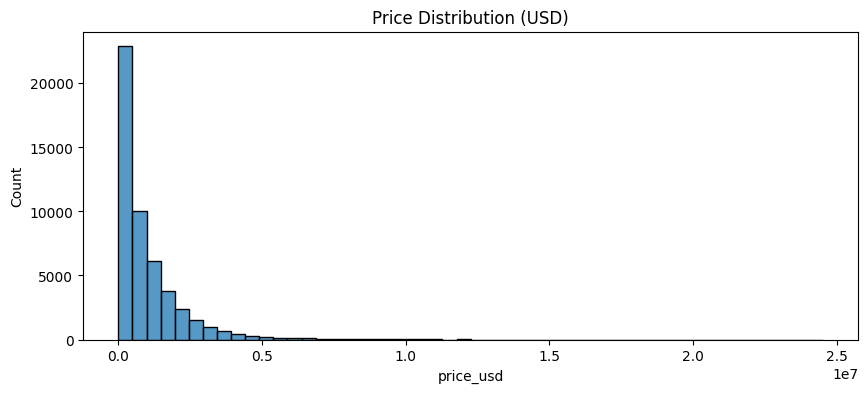

In [11]:
plt.figure(figsize=(10,4))
sns.histplot(df['price_usd'], bins=50)
plt.title('Price Distribution (USD)')
plt.show()

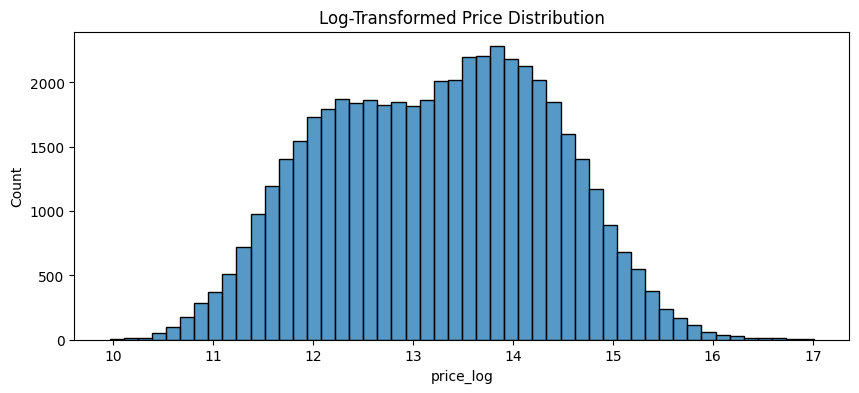

In [12]:
df['price_log'] = np.log1p(df['price_usd'])

plt.figure(figsize=(10,4))
sns.histplot(df['price_log'], bins=50)
plt.title('Log-Transformed Price Distribution')
plt.show()

In [13]:
df.groupby('community')['price_usd'].median().sort_values(ascending=False).head(15)

,price_usd
community,
Emirates Hills,3530400.0
Bulgari Resort,3074800.0
Umm Suqeim,2828950.0
Jumeirah Bay Island,2259300.0
Jumeirah Islands,2075400.0
Jumeirah Park,1837500.0
Arabian Ranches 3,1816300.0
Arabian Ranches 2,1783200.0
The Lakes,1741500.0


In [14]:
df['community'].nunique()

84

In [15]:
from sklearn.model_selection import train_test_split

# Drop columns we won't use as model inputs
drop_cols = ['id', 'date_listed', 'price_usd', 'price_log']
X = df.drop(columns=drop_cols)
y = df['price_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(40000, 27) (10000, 27)


In [16]:
# Calculate average price_log per community, using ONLY training data
community_target_map = y_train.groupby(X_train['community']).mean()

X_train['community_encoded'] = X_train['community'].map(community_target_map)
X_test['community_encoded'] = X_test['community'].map(community_target_map)

# Drop the original text column now that we have the numeric encoding
X_train = X_train.drop(columns=['community'])
X_test = X_test.drop(columns=['community'])

# Sanity check
X_train[['community_encoded']].head()

,community_encoded
39087,12.148205
30893,14.401329
45278,14.401329
16398,11.863624
13653,14.213566


In [17]:
X_test['community_encoded'].isnull().sum()


np.int64(0)

In [18]:
X_train.select_dtypes(include='object').columns

Index(['zone', 'property_category', 'property_type', 'view', 'furnishing',
       'condition', 'metro_station', 'metro_line', 'metro_distance_type'],
      dtype='object')

In [19]:
for col in ['zone', 'property_category', 'property_type', 'view', 'furnishing',
            'condition', 'metro_station', 'metro_line', 'metro_distance_type']:
    print(col, '->', X_train[col].nunique())

zone -> 52
property_category -> 2
property_type -> 9
view -> 8
furnishing -> 3
condition -> 3
metro_station -> 55
metro_line -> 2
metro_distance_type -> 2


In [20]:
for col in ['zone', 'metro_station']:
    target_map = y_train.groupby(X_train[col]).mean()
    X_train[col + '_encoded'] = X_train[col].map(target_map)
    X_test[col + '_encoded'] = X_test[col].map(target_map)
    X_train = X_train.drop(columns=[col])
    X_test = X_test.drop(columns=[col])

print(X_test['zone_encoded'].isnull().sum(), X_test['metro_station_encoded'].isnull().sum())

0 0


In [21]:
onehot_cols = ['property_category', 'property_type', 'view', 'furnishing',
               'condition', 'metro_line', 'metro_distance_type']

X_train = pd.get_dummies(X_train, columns=onehot_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=onehot_cols, drop_first=True)

print(X_train.shape, X_test.shape)

(40000, 42) (10000, 42)
